# 13 — Do the earlier image findings replicate in runs 1–3?

Notebooks 05–09 found five image-based results in runs 5/6 (25 animals). Runs 1–3 (36 sections, 42 animals) were
imaged with the same segmentation kit but stained, imaged and annotated separately, so they are an independent
replication set. Each finding is computed with the **same code** on runs 5/6 (should reproduce the earlier numbers)
and on runs 1–3:

- **(a)** 18S texture as a severity marker (notebook 05),
- **(b)** white-matter neuropil loss in lesions (notebook 06), plus the open check from notebook 11 (lesion
  neuropil index > 1 with the control-referenced reference),
- **(c)** astrocyte RNA reactivity vs vimentin protein, RNA before protein (notebook 06),
- **(d)** T-cell 18S polarity towards the nearest vessel (notebooks 06–07),
- **(e)** transfer of image-only models to an unseen run, now leave-one-run-out over five runs (notebook 09).

Data: `data/features_norm_all.parquet` (`scripts/02_normalise_all_runs.py`), lesion calls from notebook 10.
Unit = animal. Runs 1–3 hold different stages from runs 5/6 (run1 chronic incl. MILD30; runs 2/3 the RR course), so
"replicated" means the same direction and similar size, not identical numbers.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, spearmanr, wilcoxon
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

from beyondboundaries import data, plotting
from beyondboundaries import orthogonality as orth

plotting.style()
SRC = "notebooks/13_replication_runs123.ipynb"
OUT = ROOT / "results" / "13_replication_runs123"
OUT.mkdir(parents=True, exist_ok=True)
CH = data.CHANNELS
rng = np.random.default_rng(0)
SETS = {"runs 5/6": ["run5", "run6"], "runs 1–3": ["run1", "run2", "run3"]}

fa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet")
f64 = fa.select_dtypes("float64").columns
fa[f64] = fa[f64].astype(np.float32)
fa = fa.join(pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_calls.parquet")[["new_lesion", "lesion_state"]])

# Pieces touch in runs 1-3: a border cell's territory/ring partly measures the other animal's tissue.
other = pd.Series(np.inf, index=fa.index)
for _, g in fa.groupby("section_id", observed=True):
    xy, pc = g[["x_centroid", "y_centroid"]].to_numpy(), g.meta_sample_id.astype(str).to_numpy()
    for p in np.unique(pc):
        m = pc == p
        if not m.all():
            other[g.index[m]] = cKDTree(xy[~m]).query(xy[m], k=1)[0]
fa["other_piece_um"] = other
fa = fa[(fa.segmentation_method == "Segmented by interior stain (18S)") & (fa.other_piece_um >= 20)].copy()
fa["runset"] = np.where(fa.run.isin(SETS["runs 5/6"]), "runs 5/6", "runs 1–3")
fa["region_class"] = np.select([fa.Global_anatomical_region.isin(["WM", "WM_Meningeal"]),
                                fa.Global_anatomical_region.isin(["GM", "DorsalHorn", "VentralHorn"])], ["WM", "GM"],
                               "other")
fa["lesion"] = fa.Curated_niche_state.astype(str).str.startswith("Lesion")
fa["phys"] = fa.Curated_niche_state.astype(str) == "Physiological"
fa.groupby("runset").agg(cells=("run", "size"), animals=("sample_name", "nunique"), sections=("section_id", "nunique"))


def section_z(s, by):
    med = s.groupby(by, observed=True).transform("median")
    mad = (s - med).abs().groupby(by, observed=True).transform("median") * 1.4826
    return (s - med) / mad.replace(0, np.nan)


summary = []

## (a) 18S texture as a severity marker
Notebook 05: per animal × section (lumbar cells, ≥ 30 per type), median 18S Haralick correlation; Spearman with the
clinical score at sacrifice, over all animals and **within section** (each animal centred on its section's mean, so
only animals imaged together are compared). DAPI texture under the same optics is the negative control.

,runs,cell_type,animals,rho_all,rho_within_section,n_within,rho_dapi_texture
0,runs 5/6,Myeloid,25,0.76,0.84,12,0.13
1,runs 5/6,Astrocyte,25,0.72,0.84,12,-0.18
2,runs 5/6,Endothelial,25,0.71,0.86,12,0.39
3,runs 5/6,Fibroblast,25,0.67,0.67,12,0.18
4,runs 5/6,Oligodendrocyte,25,0.50,0.53,12,-0.15
5,runs 5/6,Neuron,25,0.37,0.67,12,-0.13
6,runs 1–3,Myeloid,42,0.46,0.61,18,-0.05
7,runs 1–3,Astrocyte,42,0.59,0.76,18,-0.09
8,runs 1–3,Endothelial,42,0.18,-0.01,18,0.28
9,runs 1–3,Fibroblast,42,0.32,0.09,18,0.19


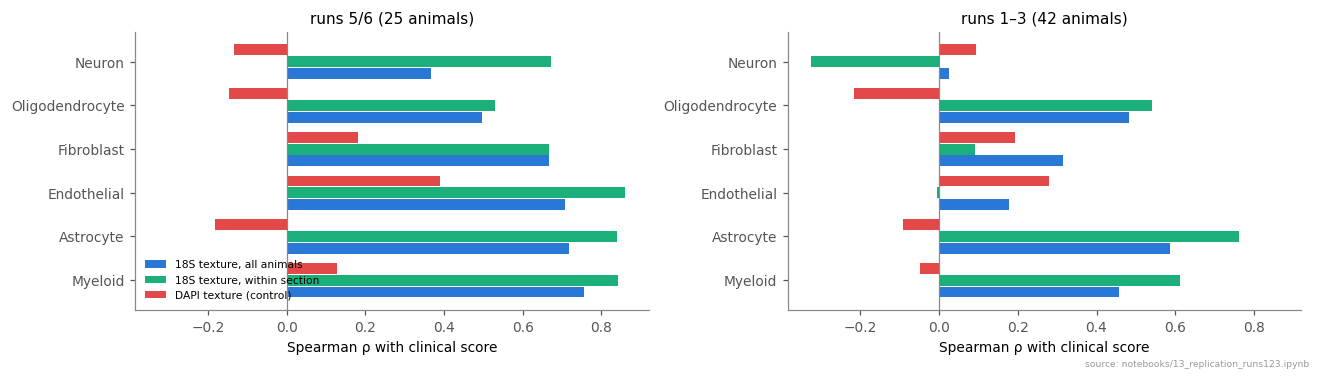

In [2]:
TEX_TYPES = ["Myeloid", "Astrocyte", "Endothelial", "Fibroblast", "Oligodendrocyte", "Neuron"]
rows = []
for rs, runs in SETS.items():
    lum = fa[(fa.runset == rs) & (fa.region == "L")]
    for t in TEX_TYPES:
        d = lum[lum.Anno_L1_curated == t]
        a = d.groupby(["section_id", "sample_name"], observed=True).agg(
            v=("r18s_glcm_correlation", "median"), dv=("dapi_glcm_correlation", "median"),
            score=("score_sacrifice", "first"), n=("section_id", "size")).reset_index().dropna(subset=["score"])
        a = a[a.n >= 30]
        a["v_w"] = a.v - a.groupby("section_id").v.transform("mean")
        a["s_w"] = a.score - a.groupby("section_id").score.transform("mean")
        b = a[(a.groupby("section_id").sample_name.transform("nunique") > 1)
              & (a.groupby("section_id").score.transform("std") > 0)]
        rows.append(dict(runs=rs, cell_type=t, animals=a.sample_name.nunique(),
                         rho_all=spearmanr(a.v, a.score).statistic,
                         rho_within_section=spearmanr(b.v_w, b.s_w).statistic, n_within=len(b),
                         rho_dapi_texture=spearmanr(a.dv, a.score).statistic))
tex = pd.DataFrame(rows)
tex.to_csv(OUT / "a_r18s_texture.csv", index=False)
fig, axs = plt.subplots(1, 2, figsize=(12, 3.4), sharex=True)
for ax, (rs, d) in zip(axs, tex.groupby("runs", sort=False)):
    d = d.set_index("cell_type").loc[TEX_TYPES]
    y = np.arange(len(d))
    for k, (col, lab) in enumerate([("rho_all", "18S texture, all animals"),
                                    ("rho_within_section", "18S texture, within section"),
                                    ("rho_dapi_texture", "DAPI texture (control)")]):
        ax.barh(y + (k - 1) * 0.27, d[col], height=0.25, color=plotting.CATEGORICAL[[0, 2, 7][k]], label=lab)
    ax.axvline(0, color="#888888", lw=0.8)
    ax.set_yticks(y, d.index); ax.set_title(f"{rs} ({int(d.animals.max())} animals)")
    ax.set_xlabel("Spearman ρ with clinical score")
axs[0].legend(fontsize=7, loc="lower left")
fig.tight_layout()
plotting.save_fig(fig, "a_r18s_texture", OUT, SRC)
tex.round(2)

In [3]:
for rs in SETS:
    d = tex[tex.runs == rs]
    summary.append(dict(finding="(a) 18S texture vs score, within section (median ρ over 6 types)", runs=rs,
                        value=d.rho_within_section.median()))
    summary.append(dict(finding="(a) DAPI texture vs score (control, median ρ)", runs=rs, value=d.rho_dapi_texture.median()))

## (b) White-matter neuropil loss in lesions
Notebook 06: neuropil index = raw ATP1A1 in the 10 µm territory ÷ the median of all cells of the same piece × WM/GM.
Paired within piece (≥ 100 cells each): lesion-niche vs physiological-niche cells (curated labels), Wilcoxon over
pieces. Repeated with notebook 10's control-referenced calls (lesion vs "no lesion").

In [4]:
fa["bnd_terr_raw"] = fa.bnd_terr_mean * fa.bnd_scale + fa.bnd_bg_local
ni = fa[fa.region_class.isin(["WM", "GM"])].copy()
key = ni.meta_sample_id.astype(str) + "|" + ni.region_class
ni["index_nb06"] = ni.bnd_terr_raw / ni.bnd_terr_raw.groupby(key).transform("median")
ni["les10"] = ni.new_lesion == 1
ni["nol10"] = ni.lesion_state == "no lesion"
rows = []
for rs in SETS:
    for (pc, cl), g in ni[ni.runset == rs].groupby(["meta_sample_id", "region_class"], observed=True):
        for calls, L, P in [("curated niches", g.lesion, g.phys), ("control-referenced", g.les10, g.nol10)]:
            if L.sum() >= 100 and P.sum() >= 100:
                rows.append(dict(runs=rs, calls=calls, piece=pc, region_class=cl,
                                 lesion=g.loc[L, "index_nb06"].median(), phys=g.loc[P, "index_nb06"].median()))
pp = pd.DataFrame(rows)
pp["diff"] = pp.lesion - pp.phys
pp["ratio"] = pp.lesion / pp.phys
pp.to_csv(OUT / "b_neuropil_within_piece.csv", index=False)
nt = pp.groupby(["calls", "runs", "region_class"]).apply(
    lambda g: pd.Series({"pieces": len(g), "lesion ÷ physiological (median)": g.ratio.median(),
                         "Wilcoxon p": wilcoxon(g["diff"]).pvalue if len(g) >= 5 else np.nan}), include_groups=False)
nt.round(4)

pieces  \
calls              runs     region_class           
control-referenced runs 1–3 GM              77.0   
                            WM              72.0   
                   runs 5/6 GM              43.0   
                            WM              41.0   
curated niches     runs 1–3 GM              94.0   
                            WM              58.0   
                   runs 5/6 GM              45.0   
                            WM              38.0   

                                          lesion ÷ physiological (median)  \
calls              runs     region_class                                    
control-referenced runs 1–3 GM                                     1.0201   
                            WM                                     0.9293   
                   runs 5/6 GM                                     1.0319   
                            WM                                     0.9553   
curated niches     runs 1–3 GM                                     0.9629   
                            WM                                     0.7242   
                   runs 5/6 GM                                     1.0027   
                            WM                                     0.7865   

                                          Wilcoxon p  
calls              runs     region_class              
control-referenced runs 1–3 GM                0.2875  
                            WM                0.0002  
                   runs 5/6 GM                0.0768  
                            WM                0.3479  
curated niches     runs 1–3 GM                0.0255  
                            WM                0.0000  
                   runs 5/6 GM                0.6226  
                            WM                0.0000

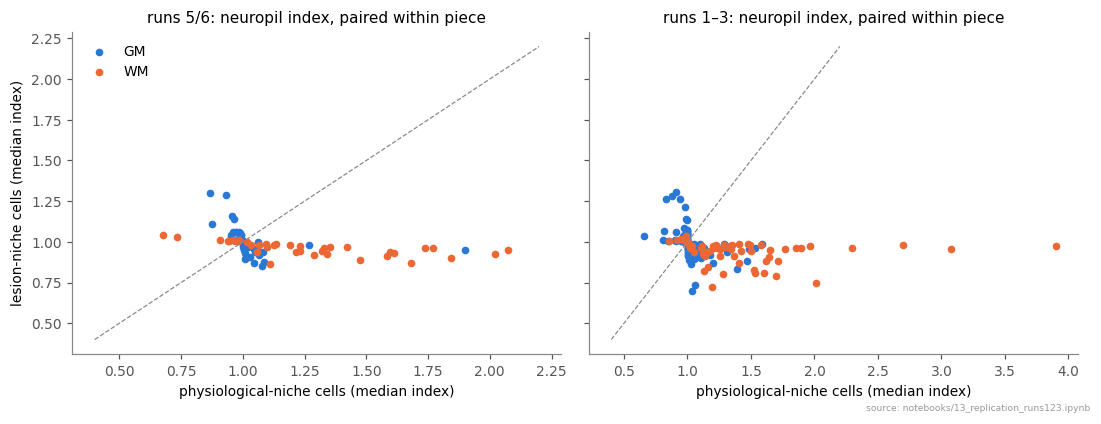

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, rs in zip(axs, SETS):
    d = pp[(pp.runs == rs) & (pp.calls == "curated niches")]
    for k, (cl, g) in enumerate(d.groupby("region_class")):
        ax.scatter(g.phys, g.lesion, s=16, color=plotting.CATEGORICAL[k], label=cl)
    ax.plot([0.4, 2.2], [0.4, 2.2], color="#888888", lw=0.8, ls="--")
    ax.set(xlabel="physiological-niche cells (median index)", title=f"{rs}: neuropil index, paired within piece")
axs[0].set_ylabel("lesion-niche cells (median index)")
axs[0].legend()
fig.tight_layout()
plotting.save_fig(fig, "b_neuropil_paired", OUT, SRC)
for rs in SETS:
    v = nt.loc[("curated niches", rs, "WM")]
    summary.append(dict(finding="(b) WM lesion ÷ physiological neuropil (curated niches)", runs=rs,
                        value=v["lesion ÷ physiological (median)"], p=v["Wilcoxon p"]))
    v = nt.loc[("control-referenced", rs, "WM")] if ("control-referenced", rs, "WM") in nt.index else None
    if v is not None:
        summary.append(dict(finding="(b) WM lesion ÷ no-lesion neuropil (control-referenced calls)", runs=rs,
                            value=v["lesion ÷ physiological (median)"], p=v["Wilcoxon p"]))

### Open check from notebook 11: why is the lesion neuropil index > 1 in some groups?
Notebook 11 divided by the median of the piece's control-referenced **non-lesion** cells of the same class; notebook 06
divided by the median of **all** cells of the piece × class. The two references are compared directly: per piece ×
class, reference_nb11 ÷ reference_nb06, and what the non-lesion cells are (share of physiological curated niche,
region composition).

reference_nb11 ÷ reference_nb06 by class (median over pieces):
              count    25%    50%    75%
region_class                            
GM            155.0  0.976  1.000  1.011
WM            138.0  0.985  1.005  1.110
Spearman ρ(ref ratio, lesion share of the piece): {'GM': -0.15, 'WM': 0.19}


,lesion_index_ref06,lesion_index_ref11
region_class,,
GM,1.008,1.026
WM,0.977,0.914


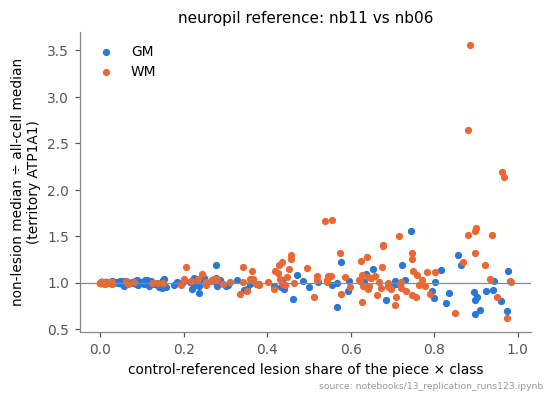

In [6]:
rows = []
for (pc, cl), g in ni.groupby(["meta_sample_id", "region_class"], observed=True):
    if g.nol10.sum() < 100:
        continue
    r06, r11 = g.bnd_terr_raw.median(), g.loc[g.nol10, "bnd_terr_raw"].median()
    rows.append(dict(piece=pc, region_class=cl, runs=g.runset.iloc[0], stage=g.stage.iloc[0],
                     lesion_share=g.les10.mean(), ref11_over_ref06=r11 / r06,
                     lesion_index_ref06=g.loc[g.les10, "index_nb06"].median() if g.les10.sum() >= 50 else np.nan,
                     lesion_index_ref11=(g.loc[g.les10, "bnd_terr_raw"] / r11).median() if g.les10.sum() >= 50 else np.nan,
                     nolesion_GM_subregion_share=(g.loc[g.nol10, "Global_anatomical_region"] != "GM").mean()
                     if cl == "GM" else np.nan))
refc = pd.DataFrame(rows)
refc.to_csv(OUT / "b_reference_comparison.csv", index=False)
print("reference_nb11 ÷ reference_nb06 by class (median over pieces):")
print(refc.groupby("region_class").ref11_over_ref06.describe()[["count", "25%", "50%", "75%"]].round(3))
print("Spearman ρ(ref ratio, lesion share of the piece):",
      refc.groupby("region_class").apply(lambda g: spearmanr(g.lesion_share, g.ref11_over_ref06).statistic,
                                          include_groups=False).round(2).to_dict())
fig, ax = plt.subplots(figsize=(5, 3.6))
for k, (cl, g) in enumerate(refc.groupby("region_class")):
    ax.scatter(g.lesion_share, g.ref11_over_ref06, s=14, color=plotting.CATEGORICAL[k], label=cl)
ax.axhline(1, color="#888888", lw=0.8)
ax.set(xlabel="control-referenced lesion share of the piece × class",
       ylabel="non-lesion median ÷ all-cell median\n(territory ATP1A1)", title="neuropil reference: nb11 vs nb06")
ax.legend()
fig.tight_layout()
plotting.save_fig(fig, "b_reference_comparison", OUT, SRC)
refc.groupby("region_class")[["lesion_index_ref06", "lesion_index_ref11"]].median().round(3)

## (c) Astrocyte RNA reactivity vs vimentin protein
Notebook 06: RNA score = mean gene-z of reactive minus homeostatic genes (z over the astrocytes of the run set),
within-section robust z; protein score = (vimentin-channel cell mean + cytoplasmic p90 − ATP1A1 rim) / 3, each a
within-section robust z. Quadrants = top/bottom 25 % within section. "RNA-only" = reactive transcription with quiet
vimentin. Phase per animal: active (OS1/ONSET, PEAK, MILD, SEVERE), recovery (REMISSION*, MONOPHASIC), pre/none.

In [7]:
REACTIVE = ["C3", "Gfap", "Serpina3n", "Cd44", "Osmr", "Timp1", "Socs3", "Serping1", "H2-D1", "Psmb8", "Gbp2"]
HOMEO = ["Slc1a3", "Kcnj10", "Slc6a11", "Fgfr3", "Gjb6", "Aldoc", "Aldh1l1"]
adata = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad")
gi = {g: i for i, g in enumerate(adata.var_names)}
ast = fa[fa.Anno_L1_curated == "Astrocyte"].copy()
Xc = adata[ast.index].layers["counts"]
del adata
Xln = orth.lognorm(Xc)


def gene_z(rows, genes):
    M = Xln[rows][:, [gi[g] for g in genes]].toarray()
    return ((M - M.mean(0)) / M.std(0)).mean(1)


for rs in SETS:
    r = np.flatnonzero((ast.runset == rs).to_numpy())
    ast.loc[ast.index[r], "rna_raw"] = gene_z(r, REACTIVE) - gene_z(r, HOMEO)
ast["rna_score"] = section_z(ast.rna_raw, ast.section_id)
ast["prot_score"] = (section_z(ast.smavim_cell_mean, ast.section_id) + section_z(ast.smavim_cyto_p90, ast.section_id)
                     - section_z(ast.bnd_rim_mean, ast.section_id)) / 3
q = lambda s: s.groupby(ast.section_id, observed=True).transform(lambda x: x.rank(pct=True))
pr, rr = q(ast.prot_score), q(ast.rna_score)
ast["quadrant"] = np.select([(pr > .75) & (rr > .75), (pr < .25) & (rr < .25), (pr > .75) & (rr < .25),
                             (pr < .25) & (rr > .75)], ["both high", "both low", "protein-only", "RNA-only"], "middle")
st = ast.stage.astype(str)
ast["phase"] = np.select([st.str.startswith("REMISSION") | (st == "MONOPHASIC"),
                          st.str.contains("PEAK|SEVERE|MILD|OS1|ONSET")], ["recovery", "active"], "pre/none")
rho_run = ast.groupby("run").apply(lambda g: spearmanr(g.prot_score, g.rna_score, nan_policy="omit").statistic,
                                   include_groups=False)
print("protein vs RNA reactivity, Spearman ρ per run:", rho_run.round(3).to_dict())
ex = ast[ast.quadrant != "middle"]
pa = ex.groupby("sample_name", observed=True).agg(
    runs=("runset", "first"), phase=("phase", "first"), stage=("stage", "first"),
    rna_only=("quadrant", lambda s: (s == "RNA-only").mean()),
    protein_only=("quadrant", lambda s: (s == "protein-only").mean()),
    rna_only_in_lesion=("lesion", lambda s: s[ex.loc[s.index, "quadrant"] == "RNA-only"].mean()), n=("quadrant", "size"))
pa = pa[pa.n >= 50]
pa["protein_only_minus_rna_only"] = pa.protein_only - pa.rna_only
pa.to_csv(OUT / "c_astro_quadrants_per_animal.csv")
tab = pa.groupby(["runs", "phase"])[["rna_only", "protein_only", "protein_only_minus_rna_only"]].median()
tab["animals"] = pa.groupby(["runs", "phase"]).size()
tab.round(3)

protein vs RNA reactivity, Spearman ρ per run: {'run1': 0.582, 'run2': 0.525, 'run3': 0.513, 'run5': 0.492, 'run6': 0.457}


rna_only  protein_only  protein_only_minus_rna_only  \
runs     phase                                                           
runs 1–3 active       0.076         0.018                       -0.050   
         pre/none     0.034         0.027                       -0.022   
         recovery     0.046         0.033                       -0.012   
runs 5/6 active       0.111         0.019                       -0.082   
         pre/none     0.036         0.064                        0.037   
         recovery     0.071         0.020                       -0.033   

                   animals  
runs     phase              
runs 1–3 active         25  
         pre/none        9  
         recovery        8  
runs 5/6 active         16  
         pre/none        4  
         recovery        5

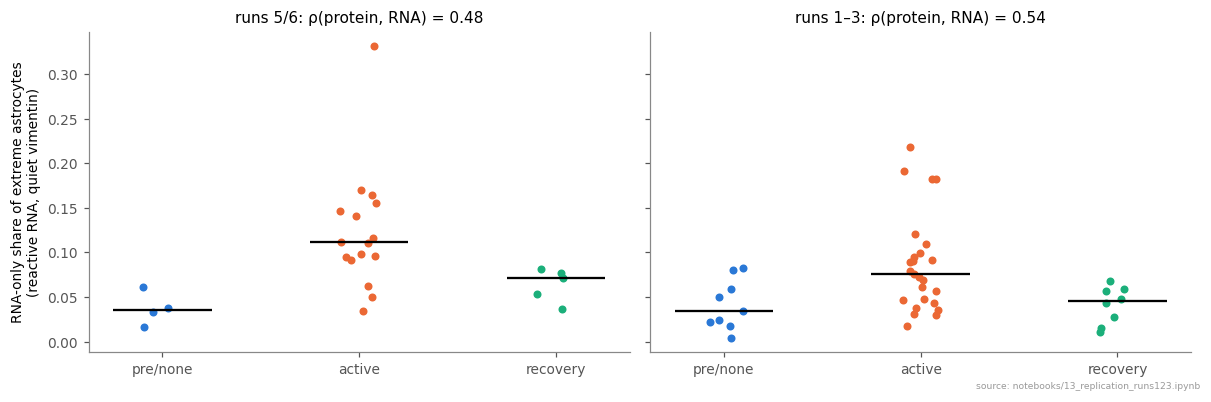

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, rs in zip(axs, SETS):
    d = pa[pa.runs == rs]
    for k, ph in enumerate(["pre/none", "active", "recovery"]):
        v = d[d.phase == ph].rna_only
        ax.scatter(np.full(len(v), k) + rng.uniform(-0.1, 0.1, len(v)), v, s=18, color=plotting.CATEGORICAL[k])
        if len(v):
            ax.hlines(v.median(), k - 0.25, k + 0.25, color="black", lw=1.5)
    ax.set_xticks(range(3), ["pre/none", "active", "recovery"])
    ax.set_title(f"{rs}: ρ(protein, RNA) = {spearmanr(ast[ast.runset == rs].prot_score, ast[ast.runset == rs].rna_score, nan_policy='omit').statistic:.2f}")
axs[0].set_ylabel("RNA-only share of extreme astrocytes\n(reactive RNA, quiet vimentin)")
fig.tight_layout()
plotting.save_fig(fig, "c_astro_rna_only", OUT, SRC)
for rs in SETS:
    d = pa[pa.runs == rs]
    a_, r_ = d[d.phase == "active"].rna_only, d[d.phase == "recovery"].rna_only
    summary.append(dict(finding="(c) ρ protein vs RNA reactivity (astrocytes)", runs=rs,
                        value=spearmanr(ast[ast.runset == rs].prot_score, ast[ast.runset == rs].rna_score,
                                        nan_policy="omit").statistic))
    summary.append(dict(finding="(c) RNA-only share: active − recovery (median)", runs=rs,
                        value=a_.median() - r_.median(), p=mannwhitneyu(a_, r_).pvalue if min(len(a_), len(r_)) >= 3 else np.nan))
    summary.append(dict(finding="(c) RNA-only share: pre/none (median)", runs=rs, value=d[d.phase == "pre/none"].rna_only.median()))

## (d) T-cell 18S polarity towards the nearest vessel
Cosine between each cell's 18S polarity vector and the direction to the nearest endothelial/VSMC cell in the same
piece, for cells < 15 µm from a vessel cell. Per animal mean (≥ 20 cells), median over animals, Wilcoxon against 0.
Neurons and oligodendrocytes are the negative control (no expected polarity; positive = optical bleed).

In [9]:
vessel = fa.Anno_L1_curated.isin(["Endothelial", "VSMC"]).to_numpy()
nv = orth.nearest_of(fa, vessel)
fa["vdist"], fa["vx"], fa["vy"] = nv.dist_um, nv.dx_um, nv.dy_um
fa["cos18s"] = (fa.r18s_polarity_dx_um * fa.vx + fa.r18s_polarity_dy_um * fa.vy) / (
    np.hypot(fa.r18s_polarity_dx_um, fa.r18s_polarity_dy_um) * np.hypot(fa.vx, fa.vy))
POL = {"T cell": fa.Anno_L1_curated == "T cell", "MDM": fa.Anno_L2 == "MDM", "Microglia": fa.Anno_L2 == "Microglia",
       "Fibroblast": fa.Anno_L1_curated == "Fibroblast", "Neuron (control)": fa.Anno_L1_curated == "Neuron",
       "Oligodendrocyte (control)": fa.Anno_L1_curated == "Oligodendrocyte"}
rows = []
for rs in SETS:
    for name, m in POL.items():
        d = fa[m & (fa.runset == rs) & (fa.vdist > 0) & (fa.vdist < 15)]
        an = d.groupby("sample_name", observed=True).cos18s.agg(["mean", "size"])
        an = an[an["size"] >= 20]["mean"]
        rows.append(dict(runs=rs, cells=name, n_cells=len(d), animals=len(an), cos_median=an.median(),
                         p=wilcoxon(an).pvalue if len(an) >= 5 else np.nan))
pol = pd.DataFrame(rows)
pol.to_csv(OUT / "d_polarity_towards_vessel.csv", index=False)
for rs in SETS:
    v = pol[(pol.runs == rs) & (pol.cells == "T cell")].iloc[0]
    summary.append(dict(finding="(d) T-cell 18S polarity towards vessel (median cos)", runs=rs, value=v.cos_median, p=v.p))
    v = pol[(pol.runs == rs) & (pol.cells == "Neuron (control)")].iloc[0]
    summary.append(dict(finding="(d) neuron control (median cos)", runs=rs, value=v.cos_median, p=v.p))
pol.pivot(index="cells", columns="runs", values="cos_median").round(3)

runs,runs 1–3,runs 5/6
cells,,
Fibroblast,0.233,0.168
MDM,0.132,0.064
Microglia,0.096,0.045
Neuron (control),-0.007,0.002
Oligodendrocyte (control),0.016,-0.013
T cell,0.192,0.142


## (e) Image-only models on an unseen run: leave one run out
Same features and model as notebook 09 (cell features + 15- and 50-cell image neighbourhood means; gradient-boosted
trees, balanced subsample). Train on four runs, test on the fifth. Lesion vs physiological with the curated niches
(as in notebooks 08/09) and with the control-referenced calls; cell type over the 14 L1 types (≤ 3,000 cells per type
for training and testing).

/Users/christoffer/work/karolinska/development/BeyondBoundaries/src/beyondboundaries/orthogonality.py:166: RuntimeWarning: Mean of empty slice
  out[idx] = np.nanmean(vals[idx][nn[:, 1:]], axis=1)


/tmp/ipykernel_39040/21097764.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[NBH] = orth.neighbourhood_mean(fa, NB_BASE, 15)
/tmp/ipykernel_39040/21097764.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[NBH] = orth.neighbourhood_mean(fa, NB_BASE, 15)
/tmp/ipykernel_39040/21097764.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-

/tmp/ipykernel_39040/21097764.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[NBH50] = orth.neighbourhood_mean(fa, NB_BASE, 50)
/tmp/ipykernel_39040/21097764.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fa[NBH50] = orth.neighbourhood_mean(fa, NB_BASE, 50)
/tmp/ipykernel_39040/21097764.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a

,task,held_out,score,median_per_animal,animals,metric,chance
0,lesion (curated niches),run1,0.886,0.871,18.0,AUROC,NaN
1,lesion (curated niches),run2,0.881,0.866,12.0,AUROC,NaN
2,lesion (curated niches),run3,0.891,0.872,12.0,AUROC,NaN
3,lesion (curated niches),run5,0.876,0.875,18.0,AUROC,NaN
4,lesion (curated niches),run6,0.892,0.907,6.0,AUROC,NaN
5,lesion (control-referenced),run1,0.907,0.877,15.0,AUROC,NaN
6,lesion (control-referenced),run2,0.870,0.859,12.0,AUROC,NaN
7,lesion (control-referenced),run3,0.884,0.860,12.0,AUROC,NaN
8,lesion (control-referenced),run5,0.847,0.844,15.0,AUROC,NaN
9,lesion (control-referenced),run6,0.880,0.903,6.0,AUROC,NaN


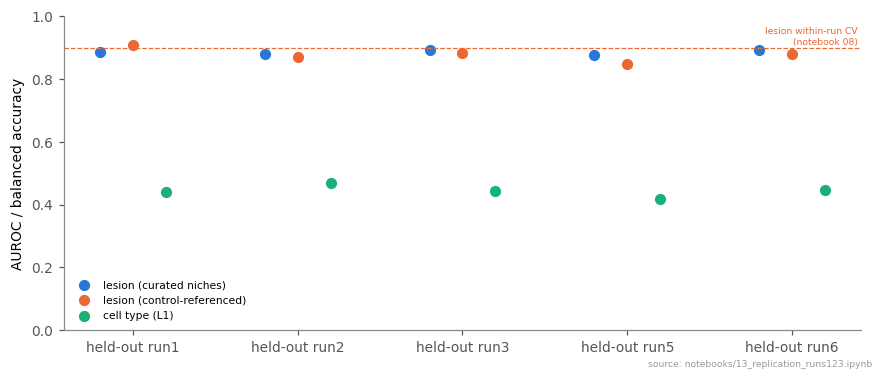

In [10]:
for ch in CH:
    fa[f"{ch}_rim_over_ring"] = (fa[f"{ch}_rim_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"]) / \
                                (fa[f"{ch}_ring_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"])
num = fa.select_dtypes("number").columns
fa[num] = fa[num].replace([np.inf, -np.inf], np.nan)
CELL = []
for ch in CH:
    CELL += [f"{ch}_{c}_{s}" for c in ("nuc", "cyto", "rim", "ring", "terr") for s in ("mean", "p90")]
    CELL += [f"{ch}_radial_b{k}" for k in range(5)]
    CELL += [f"{ch}_polarity_shape", f"{ch}_polarity_nuc", f"{ch}_rim_over_ring"]
    CELL += [f"{ch}_glcm_{k}" for k in ("contrast", "homogeneity", "asm", "entropy", "correlation")]
CELL += [c for c in fa.columns if c.startswith("morph_") and c != "morph_cell_orientation"] + ["nuc_offset", "edge_um"]
NB_BASE = [f"{ch}_{c}_mean" for ch in CH for c in ("nuc", "cyto", "terr")] + \
          [f"{ch}_glcm_{k}" for ch in CH for k in ("contrast", "correlation")] + \
          ["morph_cell_area_um2", "morph_nuc_cell_ratio", "morph_cell_eccentricity"]
NBH, NBH50 = [f"nbhd_{c}" for c in NB_BASE], [f"nbhd50_{c}" for c in NB_BASE]
fa[NBH] = orth.neighbourhood_mean(fa, NB_BASE, 15)
fa[NBH50] = orth.neighbourhood_mean(fa, NB_BASE, 50)
FEATS = CELL + NBH + NBH50


def fit(train, feats, y="y", per_class=20000):
    sub = np.concatenate([rng.choice(g.index.values, min(len(g), per_class), replace=False)
                          for _, g in train.groupby(y)])
    return HistGradientBoostingClassifier(max_iter=300, early_stopping=True, random_state=0,
                                          class_weight="balanced").fit(train.loc[sub, feats].values,
                                                                        train.loc[sub, y].values)


RUNS = ["run1", "run2", "run3", "run5", "run6"]
rows = []
for calls in ["curated niches", "control-referenced"]:
    if calls == "curated niches":
        les = fa[fa.lesion | fa.phys].copy()
        les["y"] = les.lesion.astype(int)
    else:
        les = fa[fa.new_lesion.notna()].copy()
        les["y"] = (les.new_lesion == 1).astype(int)
    for te_run in RUNS:
        tr, te = les[les.run != te_run], les[les.run == te_run]
        if te.y.nunique() < 2:
            continue
        te = te.loc[rng.choice(te.index.values, min(len(te), 150_000), replace=False)]
        p = fit(tr, FEATS).predict_proba(te[FEATS].values)[:, 1]
        per_an = [roc_auc_score(g.y, p[te.index.get_indexer(g.index)]) for _, g in te.groupby("sample_name", observed=True)
                  if min(g.y.sum(), (1 - g.y).sum()) >= 50]
        rows.append(dict(task=f"lesion ({calls})", held_out=te_run, score=roc_auc_score(te.y, p),
                         median_per_animal=np.median(per_an), animals=len(per_an), metric="AUROC"))
vc = fa.Anno_L1_curated.value_counts()
TYPES = [t for t in vc.index if vc[t] >= 500 and t not in ("Doublet", "T_B_doublet")]
ct = fa[fa.Anno_L1_curated.isin(TYPES)].copy()
ct["y"] = ct.Anno_L1_curated.astype(str)
for te_run in RUNS:
    tr, te = ct[ct.run != te_run], ct[ct.run == te_run]
    te = te.loc[np.concatenate([rng.choice(g.index.values, min(len(g), 3000), replace=False) for _, g in te.groupby("y")])]
    pred = fit(tr, CELL + NBH, per_class=3000).predict(te[CELL + NBH].values)
    rows.append(dict(task="cell type (L1)", held_out=te_run, score=balanced_accuracy_score(te.y, pred),
                     chance=1 / te.y.nunique(), metric="balanced accuracy"))
lor = pd.DataFrame(rows)
lor.to_csv(OUT / "e_leave_one_run_out.csv", index=False)
fig, ax = plt.subplots(figsize=(8, 3.4))
for k, (task, d) in enumerate(lor.groupby("task", sort=False)):
    ax.scatter(np.arange(len(d)) + k * 0.2 - 0.2, d.score, s=40, color=plotting.CATEGORICAL[k], label=task)
ax.set_xticks(range(len(RUNS)), [f"held-out {r}" for r in RUNS])
ax.set_ylabel("AUROC / balanced accuracy"); ax.set_ylim(0, 1)
ax.axhline(0.90, color=plotting.CATEGORICAL[1], lw=0.8, ls="--")
ax.text(4.4, 0.91, "lesion within-run CV\n(notebook 08)", fontsize=6, color=plotting.CATEGORICAL[1], ha="right")
ax.legend(fontsize=7, loc="lower left")
fig.tight_layout()
plotting.save_fig(fig, "e_leave_one_run_out", OUT, SRC)
for task, d in lor.groupby("task", sort=False):
    for rs, runs in SETS.items():
        summary.append(dict(finding=f"(e) {task}, leave-one-run-out (median over held-out runs)", runs=rs,
                            value=d[d.held_out.isin(runs)].score.median()))
lor.round(3)

## Replication summary

In [11]:
sm_long = pd.DataFrame(summary)
sm_long.to_csv(OUT / "replication_summary_long.csv", index=False)
sm = sm_long.pivot_table(index="finding", columns="runs", values="value", sort=False)[list(SETS)]
sm.to_csv(OUT / "replication_summary.csv")
sm.round(3)

runs,runs 5/6,runs 1–3
finding,,
"(a) 18S texture vs score, within section (median ρ over 6 types)",0.756,0.316
"(a) DAPI texture vs score (control, median ρ)",-0.003,0.023
(b) WM lesion ÷ physiological neuropil (curated niches),0.786,0.724
(b) WM lesion ÷ no-lesion neuropil (control-referenced calls),0.955,0.929
(c) ρ protein vs RNA reactivity (astrocytes),0.482,0.543
(c) RNA-only share: active − recovery (median),0.040,0.031
(c) RNA-only share: pre/none (median),0.036,0.034
(d) T-cell 18S polarity towards vessel (median cos),0.142,0.192
(d) neuron control (median cos),0.002,-0.007


## Findings

Runs 5/6 reproduce the earlier numbers (same code), so differences below are between run sets, not code.

> **Finding — (a) 18S texture severity marker: partly replicated.** Within section, the 18S texture ↔ score link holds
> in runs 1–3 for astrocytes (ρ 0.76; runs 5/6 0.84), myeloid cells (0.61 vs 0.84) and oligodendrocytes (0.54 vs 0.53),
> but not for endothelium (−0.01 vs 0.86), fibroblasts (0.09 vs 0.67) or neurons (−0.32 vs 0.67). DAPI texture stays
> near zero in both (control). It's a glial/myeloid marker at best, weaker than first estimated. Runs 1–3 cover other
> stages (chronic run 1, RR runs 2/3), so the score range differs.
>
> **Finding — (b) white-matter neuropil loss: replicated.** WM lesion-niche cells have less surrounding ATP1A1 than
> physiological WM of the same piece: ×0.72 in runs 1–3 (58 pieces, p < 1e-4) vs ×0.79 in runs 5/6 (38 pieces). GM
> shows no or a small loss (×0.96, p = 0.03 in runs 1–3; ×1.00 in runs 5/6). With the control-referenced calls the
> contrast is weaker (WM ×0.93, p = 2e-4 in runs 1–3; ×0.96, p = 0.35 in runs 5/6), because those calls also take in
> milder, partly lesioned tissue.
>
> **Finding — the notebook 11 "> 1" puzzle is pooling, not the reference.** The two neuropil references are the
> same within a few percent (non-lesion ÷ all-cell median: GM 1.00, WM 1.005 over pieces). With either reference, WM
> lesion cells sit below 1 (0.98 / 0.91) and GM lesion cells at or above 1 (1.01 / 1.03). Notebook 11's per-animal
> "lesion" readout pooled WM and GM lesion cells, so GM-rich animals came out ≥ 1. Use the WM-only readout for loss.
>
> **Finding — (c) astrocyte RNA reactivity vs vimentin protein: replicated.** ρ(protein, RNA) 0.51–0.58 in each of runs
> 1–3 (0.46–0.49 in runs 5/6). "RNA-only" astrocytes (reactive transcription, quiet vimentin) are more common in
> active disease than in recovery in both run sets (runs 1–3 0.076 vs 0.046, p = 0.01; runs 5/6 0.111 vs 0.071,
> p = 0.02), at baseline ~0.035 in pre/none animals: reactive RNA comes before vimentin protein.
>
> **Withdrawn (notebook 19):** (d) replicates as a *measurement*, but the measurement is an artefact (bright-neighbour
> bleed + outline geometry; brightness-matched control). Original text:
>
> ~~Finding — (d) T-cell 18S polarity towards vessels: replicated, and present in other immune cells.~~ Perivascular T
> cells point their 18S-rich cytoplasm towards the nearest vessel cell (median cos 0.19, 33 animals, p < 1e-4; runs 5/6
> 0.14), as do fibroblasts (0.23), MDM (0.13) and microglia (0.10). Neurons stay at 0 (−0.007, p = 0.11);
> oligodendrocytes show a tiny bias (0.016, p = 3e-4), a small optical-bleed floor.
>
> **Finding — (e) image-only models transfer to every unseen run.** Leave one run out (train on four, test on the
> fifth): lesion vs physiological AUROC 0.88–0.89 on each held-out run (curated niches; 0.85–0.91 with
> control-referenced calls), cell type balanced accuracy 0.42–0.47 (chance 0.07). That matches within-run
> cross-validation (0.90 / 0.46), now over five runs, three batches and two XOA versions.